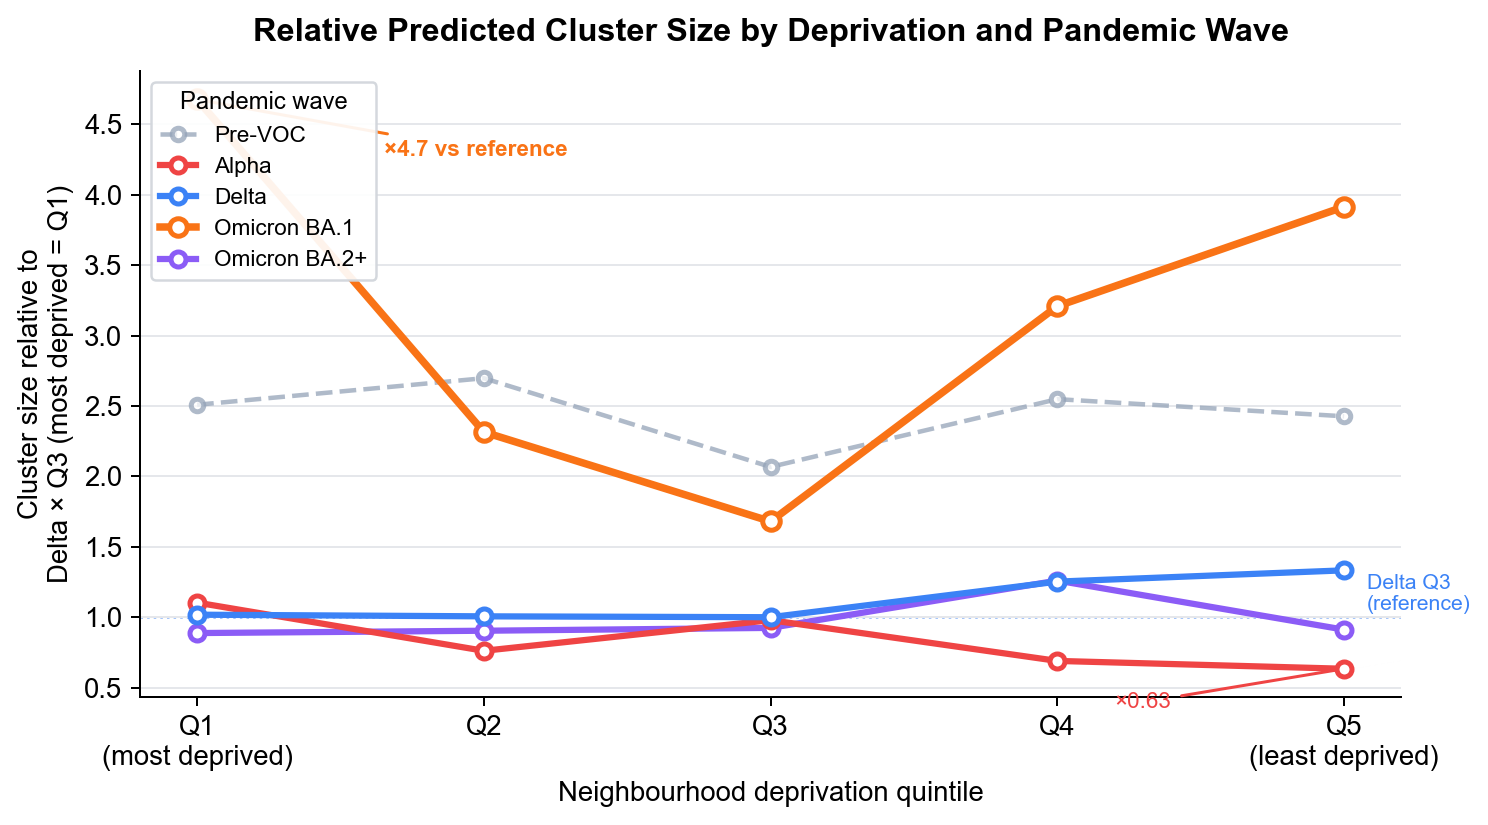

Figure 1 saved.


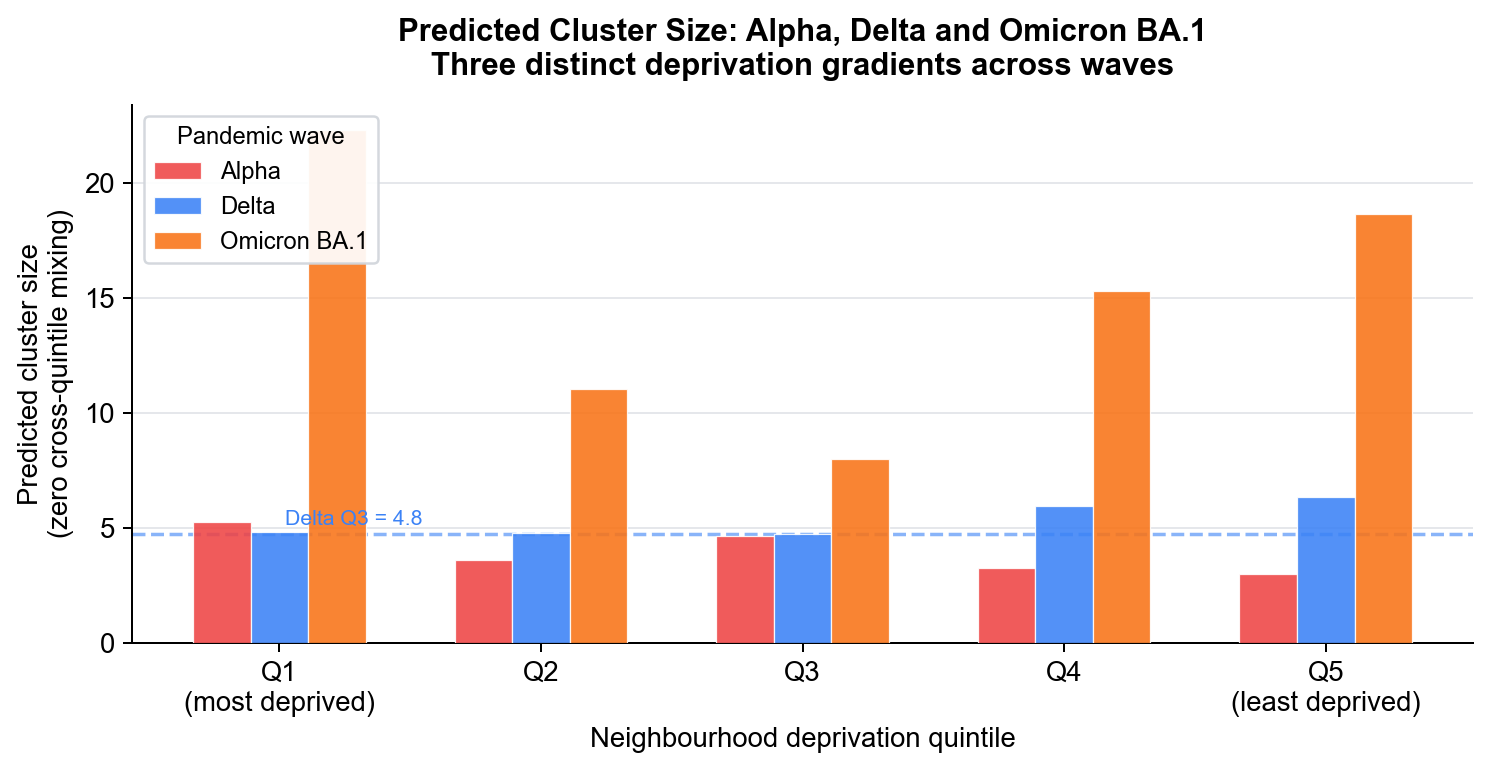

Figure 2 saved.


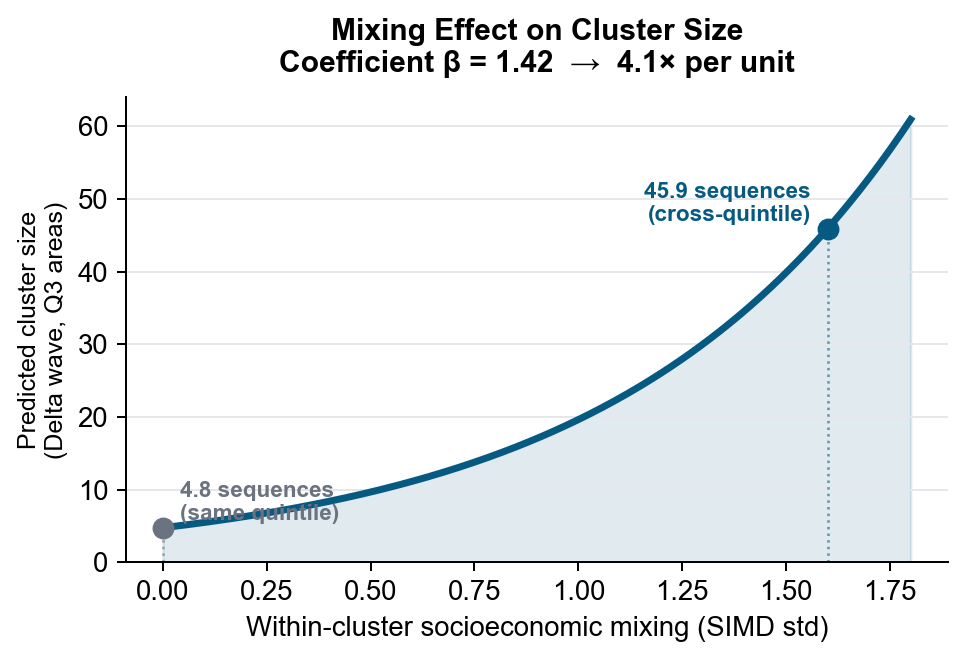

Figure 3 saved.

All figures done.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    12,
    "axes.titlesize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        180,
})

# ── Model coefficients ────────────────────────────────────────────────────────
INTERCEPT     = 1.5624
SIMD_STD_COEF = 1.4150

epoch_coef = {
    "Pre-VOC":       0.7263,
    "Alpha":        -0.0212,
    "Delta":         0.0000,
    "Omicron BA.1":  0.5189,
    "Omicron BA.2+": -0.0789,
}
simd_coef = {1: 0.0177, 2: 0.0062, 3: 0.0000, 4: 0.2254, 5: 0.2874}
interaction = {
    ("Pre-VOC",       1):  0.1759, ("Pre-VOC",       2):  0.2599,
    ("Pre-VOC",       4): -0.0160, ("Pre-VOC",       5): -0.1270,
    ("Alpha",         1):  0.1021, ("Alpha",         2): -0.2575,
    ("Alpha",         4): -0.5759, ("Alpha",         5): -0.7222,
    ("Omicron BA.1",  1):  1.0062, ("Omicron BA.1",  2):  0.3145,
    ("Omicron BA.1",  4):  0.4218, ("Omicron BA.1",  5):  0.5587,
    ("Omicron BA.2+", 1): -0.0583, ("Omicron BA.2+", 2): -0.0283,
    ("Omicron BA.2+", 4):  0.0848, ("Omicron BA.2+", 5): -0.3012,
}

EPOCHS = ["Pre-VOC", "Alpha", "Delta", "Omicron BA.1", "Omicron BA.2+"]
SIMD_QS = [1, 2, 3, 4, 5]

def eta(epoch, simd_q, simd_std=0.0):
    return (INTERCEPT + epoch_coef[epoch] + simd_coef[simd_q]
            + interaction.get((epoch, simd_q), 0.0)
            + SIMD_STD_COEF * simd_std)

def pred(epoch, simd_q, simd_std=0.0):
    return np.exp(eta(epoch, simd_q, simd_std))

# Ratios relative to Delta Q3
ref = pred("Delta", 3)
ratio = {(e, q): pred(e, q) / ref for e in EPOCHS for q in SIMD_QS}

EPOCH_COLORS = {
    "Pre-VOC":       "#94A3B8",
    "Alpha":         "#EF4444",
    "Delta":         "#3B82F6",
    "Omicron BA.1":  "#F97316",
    "Omicron BA.2+": "#8B5CF6",
}
SIMD_LABELS    = ["Q1\n(most deprived)", "Q2", "Q3", "Q4", "Q5\n(least deprived)"]
FOCUS_EPOCHS   = ["Alpha", "Delta", "Omicron BA.1"]


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Interaction ratio plot (4 epochs + reference baseline)
#            Y = ratio vs Delta × Q3
# ═══════════════════════════════════════════════════════════════════════════════
x = np.arange(len(SIMD_QS))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.set_facecolor("white"); fig.patch.set_facecolor("white")
ax.grid(axis="y", color="#E5E7EB", linewidth=0.8, zorder=0)
ax.axhline(1.0, color="#3B82F6", lw=1.0, linestyle=":", alpha=0.6, zorder=1)
ax.text(4.08, 1.02, "Delta Q3\n(reference)", fontsize=8.5, color="#3B82F6", va="bottom")

styles = {
    "Pre-VOC":       dict(lw=1.8, ls="--", ms=5, zorder=2, alpha=0.75),
    "Alpha":         dict(lw=2.5, ls="-",  ms=6, zorder=4),
    "Delta":         dict(lw=2.5, ls="-",  ms=6, zorder=4),
    "Omicron BA.1":  dict(lw=3.0, ls="-",  ms=7, zorder=5),
    "Omicron BA.2+": dict(lw=2.5, ls="-",  ms=6, zorder=3),
}

for epoch in EPOCHS:
    y = [ratio[(epoch, q)] for q in SIMD_QS]
    kw = styles[epoch]
    ax.plot(x, y, color=EPOCH_COLORS[epoch],
            marker="o", markerfacecolor="white", markeredgewidth=2,
            label=epoch, **kw)

# Annotate key points
ba1_q1_ratio = ratio[("Omicron BA.1", 1)]
ax.annotate(f"×{ba1_q1_ratio:.1f} vs reference",
            xy=(0, ba1_q1_ratio), xytext=(0.65, ba1_q1_ratio - 0.4),
            fontsize=9, color=EPOCH_COLORS["Omicron BA.1"], fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=EPOCH_COLORS["Omicron BA.1"], lw=1.2))

alpha_q5_ratio = ratio[("Alpha", 5)]
ax.annotate(f"×{alpha_q5_ratio:.2f}",
            xy=(4, alpha_q5_ratio), xytext=(3.2, alpha_q5_ratio - 0.28),
            fontsize=9, color=EPOCH_COLORS["Alpha"],
            arrowprops=dict(arrowstyle="-", color=EPOCH_COLORS["Alpha"], lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(SIMD_LABELS)
ax.set_ylabel("Cluster size relative to\nDelta × Q3 (most deprived = Q1)", fontsize=11)
ax.set_xlabel("Neighbourhood deprivation quintile", fontsize=11)
ax.set_title("Relative Predicted Cluster Size by Deprivation and Pandemic Wave",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Pandemic wave", title_fontsize=9.5, fontsize=9,
          loc="upper left", framealpha=0.92, edgecolor="#D1D5DB",
          handlelength=1.6)

plt.tight_layout(pad=1.5)
# plt.savefig("/home/claude/fig1_interaction.png", dpi=180,
#             bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 1 saved.")


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Three-epoch grouped bar chart (at SIMD std = 0)
# ═══════════════════════════════════════════════════════════════════════════════
width  = 0.22
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.set_facecolor("white"); fig.patch.set_facecolor("white")
ax.grid(axis="y", color="#E5E7EB", linewidth=0.8, zorder=0)

for epoch, offset in zip(FOCUS_EPOCHS, offsets):
    vals = [pred(epoch, q, simd_std=0) for q in SIMD_QS]
    ax.bar(x + offset, vals, width=width,
           color=EPOCH_COLORS[epoch], alpha=0.88, label=epoch,
           edgecolor="white", linewidth=0.5, zorder=3)

# Reference line
ref_val = pred("Delta", 3, simd_std=0)
ax.axhline(ref_val, color="#3B82F6", lw=1.4, linestyle="--", alpha=0.6)
ax.text(0.02, ref_val + 0.22, f"Delta Q3 = {ref_val:.1f}", fontsize=8.5,
        color="#3B82F6", va="bottom", ha="left", zorder=6)

ax.set_xticks(x)
ax.set_xticklabels(SIMD_LABELS)
ax.set_ylabel("Predicted cluster size\n(zero cross-quintile mixing)", fontsize=11)
ax.set_xlabel("Neighbourhood deprivation quintile", fontsize=11)
ax.set_title("Predicted Cluster Size: Alpha, Delta and Omicron BA.1\n"
             "Three distinct deprivation gradients across waves",
             fontsize=12.5, fontweight="bold", pad=12)
ax.legend(title="Pandemic wave", title_fontsize=9.5, fontsize=9.5,
          framealpha=0.92, edgecolor="#D1D5DB", loc="upper left")

plt.tight_layout(pad=1.5)
# plt.savefig("/home/claude/fig2_three_epochs.png", dpi=180,
#             bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 2 saved.")


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 3 — Mixing effect (SIMD std slope)
# ═══════════════════════════════════════════════════════════════════════════════
std_vals = np.linspace(0, 1.8, 300)
base_eta = INTERCEPT + epoch_coef["Delta"] + simd_coef[3]
y_vals   = np.exp(base_eta + SIMD_STD_COEF * std_vals)

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.set_facecolor("white"); fig.patch.set_facecolor("white")
ax.grid(axis="y", color="#E5E7EB", linewidth=0.8, zorder=0)
ax.fill_between(std_vals, y_vals, alpha=0.12, color="#065A82")
ax.plot(std_vals, y_vals, color="#065A82", lw=2.8)

for s_val, label, col, ha in [
    (0.0, f"{np.exp(base_eta):.1f} sequences\n(same quintile)", "#6B7280", "left"),
    (1.6, f"{np.exp(base_eta + SIMD_STD_COEF*1.6):.1f} sequences\n(cross-quintile)", "#065A82", "right"),
]:
    y_pt = np.exp(base_eta + SIMD_STD_COEF * s_val)
    ax.vlines(s_val, 0, y_pt, color=col, lw=1.0, linestyle=":", alpha=0.6)
    ax.scatter([s_val], [y_pt], color=col, s=60, zorder=5)
    offset = 0.04 if ha == "left" else -0.04
    ax.text(s_val + offset, y_pt + 0.5, label,
            fontsize=9, color=col, fontweight="bold", ha=ha, va="bottom", zorder=6)

ax.set_xlabel("Within-cluster socioeconomic mixing (SIMD std)", fontsize=11)
ax.set_ylabel("Predicted cluster size\n(Delta wave, Q3 areas)", fontsize=10)
ax.set_title("Mixing Effect on Cluster Size\nCoefficient β = 1.42  →  4.1× per unit",
             fontsize=12, fontweight="bold", pad=10)
ax.set_ylim(0, None)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=1.2)
# plt.savefig("/home/claude/fig3_mixing.png", dpi=180,
#             bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 3 saved.")

print("\nAll figures done.")